# PCA & Dimensionality Reduction Analysis
## London Urban Safety Classification

This notebook implements a complete dimensionality reduction analysis for the 4 features in your urban safety model:
- lighting, visibility, connectivity, enclosure

**Steps:**
1. Load & explore features
2. Correlation analysis
3. Standardize features
4. Apply PCA (all components)
5. Interpret loadings & variance
6. Make reduction decision
7. Compare model performance (original vs. reduced)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
sns.set_style('darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✓ All imports successful')

✓ All imports successful


## Step 1: Load & Prepare Data

**Data source:** `segment_crime_scores_w-id.csv` from notebook 02
- Features: lighting, visibility, connectivity, enclosure (all normalized)
- Target: safety_class (4 classes: 'safe', 'low', 'medium', 'high')
- Includes borough and location_id for reference


In [2]:
# ====================================================================================
# Load features with updated 4-class safety classification
# ====================================================================================

print('Loading feature data...')

# Define feature columns
FEATURE_COLS = ['lighting', 'visibility', 'connectivity', 'enclosure']

# Load from segment_crime_scores_w-id.csv (output from 02_London_ClassificationML.ipynb)
csv_path = 'csvFiles/segment_crime_scores_w-id.csv'
try:
    features = pd.read_csv(csv_path, dtype={'safety_class': str})
    print(f'✓ Loaded features from {csv_path}: {len(features)} rows')
except FileNotFoundError:
    print(f'! CSV file not found: {csv_path}')
    print('  Run 02_London_ClassificationML.ipynb first to generate segment_crime_scores_w-id.csv')
    raise

# Extract features and target
X = features[FEATURE_COLS].dropna()
y = features.loc[X.index, 'safety_class'].astype(str)

print(f'\nData shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')


Loading feature data...
✓ Loaded features from csvFiles/segment_crime_scores_w-id.csv: 35980 rows

Data shape: (35980, 4)
Target distribution:
safety_class
safe      17346
low       11338
medium     6901
high        395
Name: count, dtype: int64


## Step 2: Exploratory Data Analysis (EDA)

### 2.1 Feature Statistics & Distributions

In [3]:
# Feature statistics BEFORE scaling
print('='*70)
print('FEATURE STATISTICS (BEFORE SCALING)')
print('='*70)

stats = X.describe().T
stats['variance'] = X.var()
print(stats.round(4))

print('\nKey observations:')
print(f'  - Highest variance: {stats["variance"].idxmax()} ({stats["variance"].max():.2f})')
print(f'  - Lowest variance: {stats["variance"].idxmin()} ({stats["variance"].min():.2f})')
print(f'  - Variance ratio (max/min): {stats["variance"].max() / stats["variance"].min():.2f}x')
print('\n→ Features have different scales. StandardScaler is ESSENTIAL for PCA!')

FEATURE STATISTICS (BEFORE SCALING)
                  count    mean    std    min    25%     50%     75%      max  \
lighting     35980.0000  2.0700 5.9560 0.0000 0.0000  0.0000  1.2357 163.3943   
visibility   35980.0000  9.1190 5.5827 0.0000 8.8235  9.0000  9.6667 180.0000   
connectivity 35980.0000 10.4313 2.3257 3.0000 8.0000 11.0000 12.0000  17.0000   
enclosure    35980.0000  0.1469 0.0958 0.0000 0.0900  0.1275  0.1834   0.9941   

              variance  
lighting       35.4735  
visibility     31.1667  
connectivity    5.4089  
enclosure       0.0092  

Key observations:
  - Highest variance: lighting (35.47)
  - Lowest variance: enclosure (0.01)
  - Variance ratio (max/min): 3869.02x

→ Features have different scales. StandardScaler is ESSENTIAL for PCA!


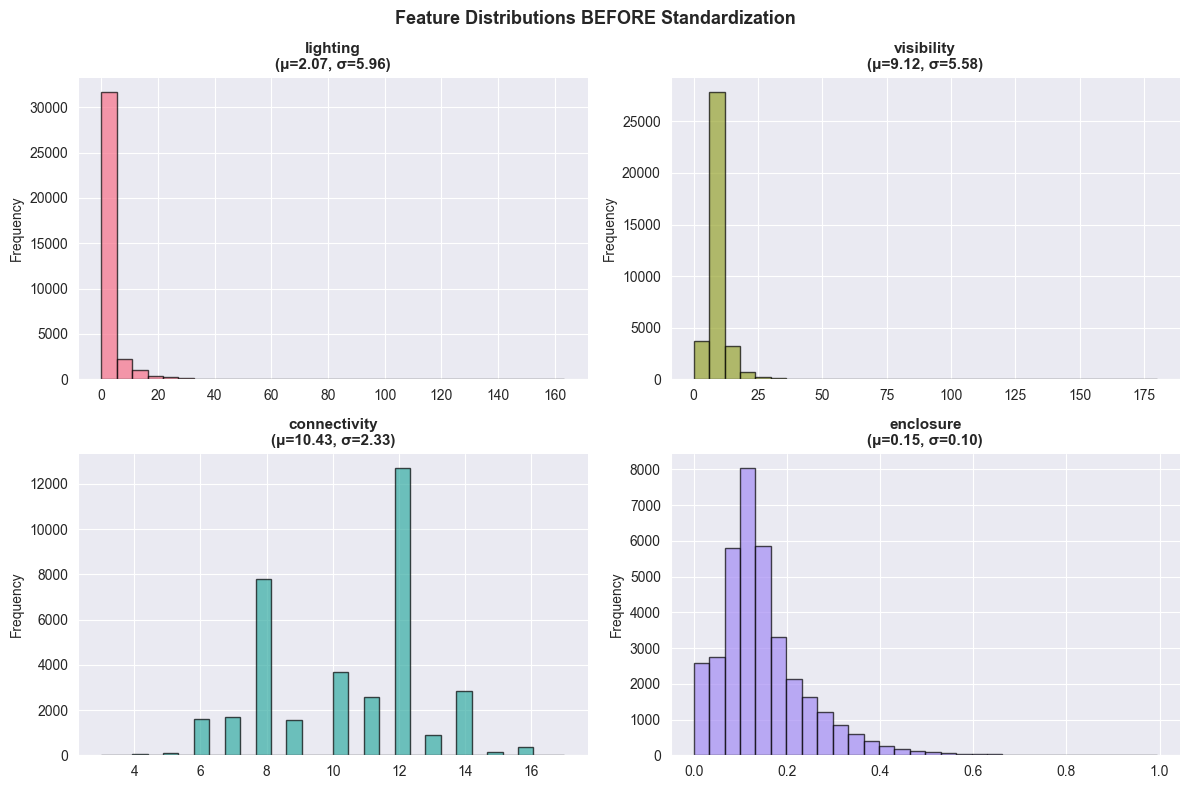

In [4]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors_palette = sns.color_palette('husl', 4)

for ax, col, color in zip(axes.flat, FEATURE_COLS, colors_palette):
    ax.hist(X[col].dropna(), bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}\n(μ={X[col].mean():.2f}, σ={X[col].std():.2f})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature Distributions BEFORE Standardization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Correlation Analysis

**Question:** Are any features highly correlated (redundant)?

In [5]:
# Compute correlation matrix
corr_matrix = X[FEATURE_COLS].corr()

print('Correlation Matrix:')
print(corr_matrix.round(3))

print('\nCorrelation Pairs (sorted by absolute value):')
# Extract upper triangle (avoid duplicates)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
        corr_val = corr_matrix.loc[col1, col2]
        corr_pairs.append((col1, col2, corr_val))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)
for col1, col2, corr_val in corr_pairs_sorted:
    print(f'  {col1:15s} ↔ {col2:15s}: {corr_val:7.3f}')

print('\nInterpretation:')
print('  |r| > 0.8  → Strong correlation (redundant features)')
print('  |r| 0.5-0.8 → Moderate correlation')
print('  |r| < 0.5  → Weak correlation (independent)')

Correlation Matrix:
              lighting  visibility  connectivity  enclosure
lighting        1.0000     -0.0410       -0.1110    -0.0280
visibility     -0.0410      1.0000        0.0220     0.4430
connectivity   -0.1110      0.0220        1.0000    -0.0450
enclosure      -0.0280      0.4430       -0.0450     1.0000

Correlation Pairs (sorted by absolute value):
  visibility      ↔ enclosure      :   0.443
  lighting        ↔ connectivity   :  -0.111
  connectivity    ↔ enclosure      :  -0.045
  lighting        ↔ visibility     :  -0.041
  lighting        ↔ enclosure      :  -0.028
  visibility      ↔ connectivity   :   0.022

Interpretation:
  |r| > 0.8  → Strong correlation (redundant features)
  |r| 0.5-0.8 → Moderate correlation
  |r| < 0.5  → Weak correlation (independent)


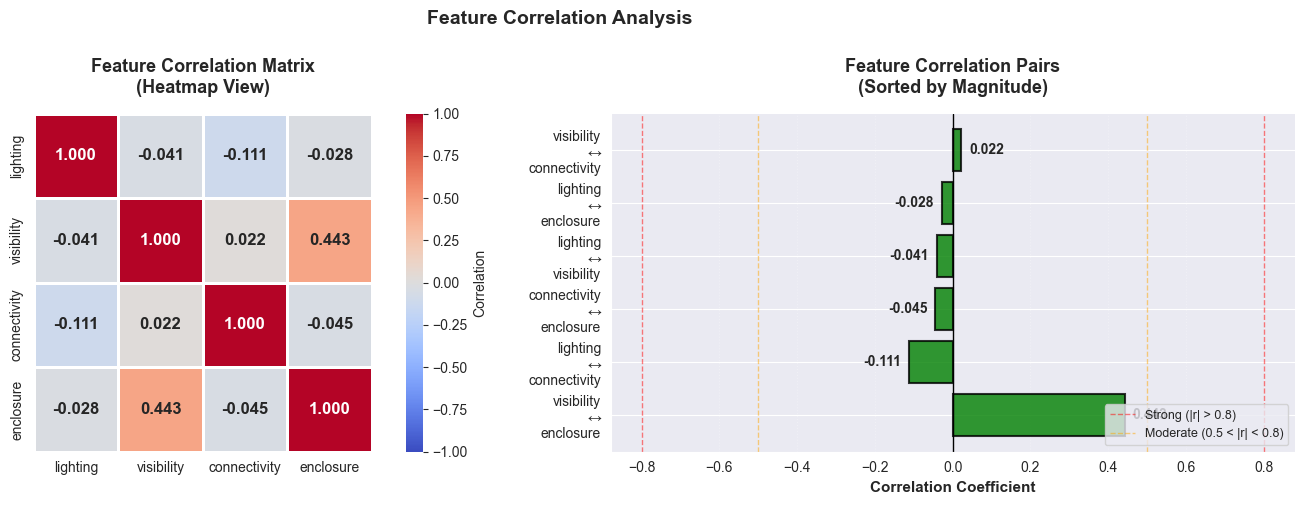

In [6]:
# Visualize correlations: Heatmap + Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Correlation Heatmap
ax1 = axes[0]
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=2, cbar_kws={'label': 'Correlation'},
            annot_kws={'fontsize': 12, 'fontweight': 'bold'}, ax=ax1)
ax1.set_title('Feature Correlation Matrix\n(Heatmap View)', fontsize=13, fontweight='bold', pad=15)

# Plot 2: Correlation Pairs as Bar Chart
ax2 = axes[1]
pair_labels = [f'{col1}\n↔\n{col2}' for col1, col2, _ in corr_pairs_sorted]
pair_values = [val for _, _, val in corr_pairs_sorted]
colors = ['green' if abs(v) < 0.5 else 'orange' if abs(v) < 0.8 else 'red' for v in pair_values]

bars = ax2.barh(range(len(pair_labels)), pair_values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_yticks(range(len(pair_labels)))
ax2.set_yticklabels(pair_labels, fontsize=10)
ax2.set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
ax2.set_title('Feature Correlation Pairs\n(Sorted by Magnitude)', fontsize=13, fontweight='bold', pad=15)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.axvline(x=0.8, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Strong (|r| > 0.8)')
ax2.axvline(x=-0.8, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax2.axvline(x=0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Moderate (0.5 < |r| < 0.8)')
ax2.axvline(x=-0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax2.grid(axis='x', alpha=0.3, linestyle=':')
ax2.legend(fontsize=9, loc='lower right')
ax2.spines[['top', 'right']].set_visible(False)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, pair_values)):
    ax2.text(val + 0.02 if val > 0 else val - 0.02, i, f'{val:.3f}', 
             va='center', ha='left' if val > 0 else 'right', fontweight='bold', fontsize=10)

plt.suptitle('Feature Correlation Analysis', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


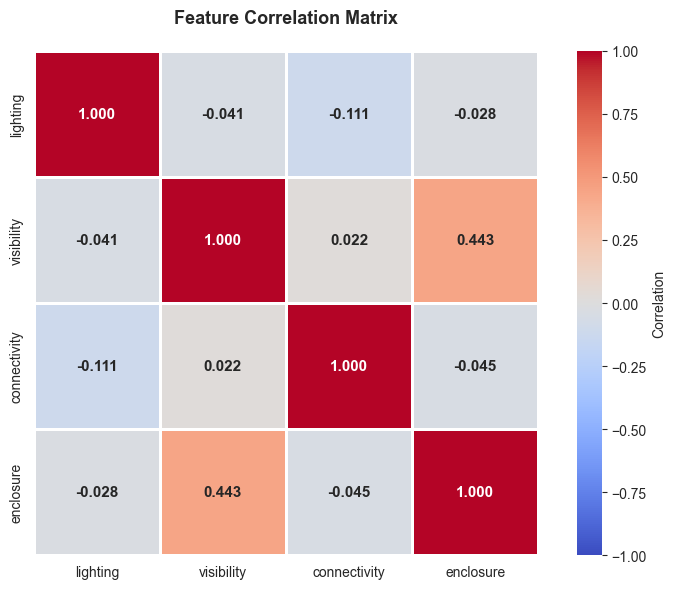

In [7]:
# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1, cbar_kws={'label': 'Correlation'},
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 2.3 Variance Inflation Factor (VIF)

**Multicollinearity assessment:** VIF measures how much a feature's variance is inflated by its correlation with other features.
- VIF < 5: Low multicollinearity ✓
- VIF 5-10: Moderate multicollinearity ⚠
- VIF > 10: High multicollinearity ✗

In [8]:
# Standardize first (VIF calculation assumes scaled data)
scaler_temp = StandardScaler()
X_scaled_temp = scaler_temp.fit_transform(X[FEATURE_COLS])

# Calculate VIF for each feature
vif_data = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'VIF': [variance_inflation_factor(X_scaled_temp, i) for i in range(len(FEATURE_COLS))]
})

vif_data = vif_data.sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print(vif_data.to_string(index=False))

print('\nInterpretation:')
for _, row in vif_data.iterrows():
    vif = row['VIF']
    if vif < 5:
        status = '✓ Low multicollinearity'
    elif vif < 10:
        status = '⚠ Moderate multicollinearity'
    else:
        status = '✗ High multicollinearity'
    print(f'  {row["Feature"]:15s}: {vif:6.2f}  {status}')

Variance Inflation Factor (VIF):
     Feature    VIF
   enclosure 1.2498
  visibility 1.2483
connectivity 1.0169
    lighting 1.0144

Interpretation:
  enclosure      :   1.25  ✓ Low multicollinearity
  visibility     :   1.25  ✓ Low multicollinearity
  connectivity   :   1.02  ✓ Low multicollinearity
  lighting       :   1.01  ✓ Low multicollinearity


## Step 3: Standardization & PCA

In [9]:
# ====================================================================================
# STANDARDIZE FEATURES
# ====================================================================================
# PCA is sensitive to feature scaling; StandardScaler ensures each feature has
# mean=0, std=1 so high-variance features don't dominate the PCA.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[FEATURE_COLS])

# Verify scaling
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS)
print('Feature Statistics AFTER StandardScaler:')
print(X_scaled_df.describe().round(4))
print('\n✓ All features now have mean ≈ 0 and std ≈ 1')

Feature Statistics AFTER StandardScaler:
        lighting  visibility  connectivity  enclosure
count 35980.0000  35980.0000    35980.0000 35980.0000
mean     -0.0000      0.0000       -0.0000    -0.0000
std       1.0000      1.0000        1.0000     1.0000
min      -0.3476     -1.6335       -3.1953    -1.5341
25%      -0.3476     -0.0529       -1.0454    -0.5939
50%      -0.3476     -0.0213        0.2445    -0.2027
75%      -0.1401      0.0981        0.6745     0.3815
max      27.0866     30.6093        2.8244     8.8475

✓ All features now have mean ≈ 0 and std ≈ 1


In [10]:
# ====================================================================================
# FIT PCA WITH ALL COMPONENTS
# ====================================================================================
# Don't specify n_components yet; fit with all to see the full picture.

pca_full = PCA()  # All components
X_pca_full = pca_full.fit_transform(X_scaled)

# Extract variance metrics
explained_variance_ratio = pca_full.explained_variance_ratio_
cumsum_explained = np.cumsum(explained_variance_ratio)

print('='*70)
print('PCA VARIANCE BREAKDOWN')
print('='*70)
for i in range(len(explained_variance_ratio)):
    pc_name = f'PC{i+1}'
    var_ratio = explained_variance_ratio[i]
    cum_ratio = cumsum_explained[i]
    bar_length = int(var_ratio * 50)  # Visual bar
    bar = '█' * bar_length + '░' * (50 - bar_length)
    print(f'{pc_name}: {var_ratio:6.1%} | {bar} | Cumulative: {cum_ratio:6.1%}')

print('\nSummary:')
print(f'  Total components: {len(explained_variance_ratio)}')
print(f'  90% variance explained by: {np.argmax(cumsum_explained >= 0.90) + 1} components')
print(f'  95% variance explained by: {np.argmax(cumsum_explained >= 0.95) + 1} components')

PCA VARIANCE BREAKDOWN
PC1:  36.2% | ██████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | Cumulative:  36.2%
PC2:  27.8% | █████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | Cumulative:  64.0%
PC3:  22.2% | ███████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | Cumulative:  86.2%
PC4:  13.8% | ██████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | Cumulative: 100.0%

Summary:
  Total components: 4
  90% variance explained by: 4 components
  95% variance explained by: 4 components


### Scree Plot & Cumulative Variance

**Scree plot:** Shows how much variance each PC captures. Look for the "elbow" where diminishing returns begin.

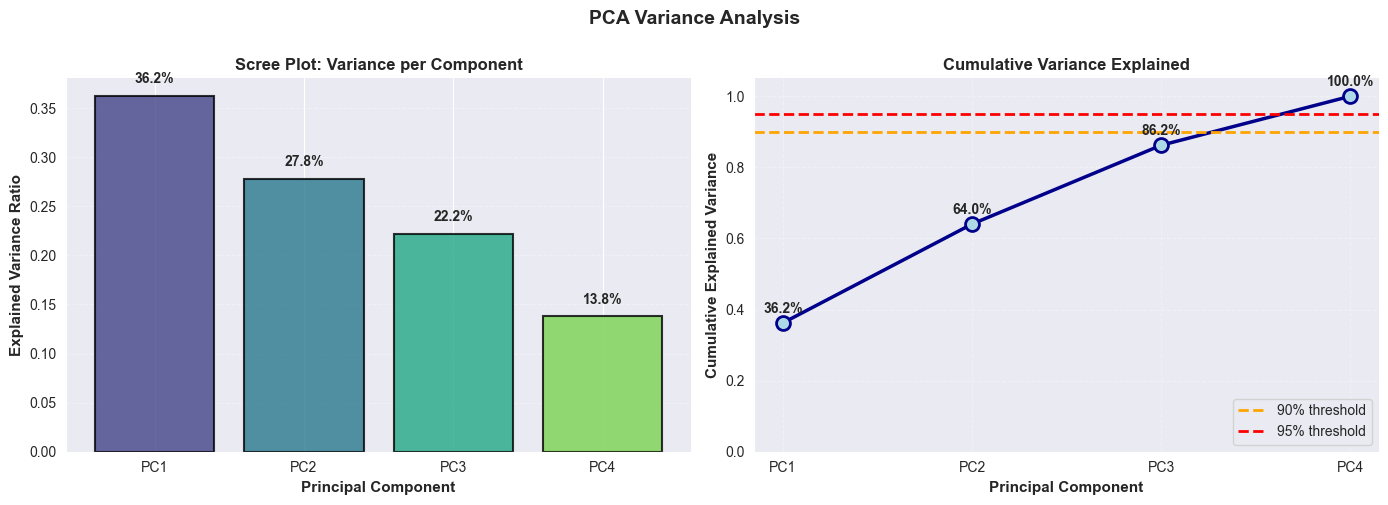

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual variance per PC
ax1 = axes[0]
pc_labels = [f'PC{i+1}' for i in range(len(explained_variance_ratio))]
colors_bar = sns.color_palette('viridis', len(explained_variance_ratio))
ax1.bar(pc_labels, explained_variance_ratio, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('Explained Variance Ratio', fontsize=11, fontweight='bold')
ax1.set_xlabel('Principal Component', fontsize=11, fontweight='bold')
ax1.set_title('Scree Plot: Variance per Component', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines[['top', 'right']].set_visible(False)

# Add value labels on bars
for i, (pc, var) in enumerate(zip(pc_labels, explained_variance_ratio)):
    ax1.text(i, var + 0.01, f'{var:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Cumulative variance
ax2 = axes[1]
ax2.plot(pc_labels, cumsum_explained, 'o-', linewidth=2.5, markersize=10, 
         color='darkblue', markerfacecolor='lightblue', markeredgewidth=2, markeredgecolor='darkblue')
ax2.axhline(y=0.90, color='orange', linestyle='--', linewidth=2, label='90% threshold')
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% threshold')
ax2.set_ylabel('Cumulative Explained Variance', fontsize=11, fontweight='bold')
ax2.set_xlabel('Principal Component', fontsize=11, fontweight='bold')
ax2.set_title('Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1.05])
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10, loc='lower right')
ax2.spines[['top', 'right']].set_visible(False)

# Add cumulative values on points
for i, (pc, cum) in enumerate(zip(pc_labels, cumsum_explained)):
    ax2.text(i, cum + 0.02, f'{cum:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('PCA Variance Analysis', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### PCA Loadings: Which Original Features Drive Each PC?

In [12]:
# Extract loadings (components)
loadings = pd.DataFrame(
    pca_full.components_,
    columns=FEATURE_COLS,
    index=[f'PC{i+1}' for i in range(len(pca_full.components_))]
)

print('='*70)
print('PCA LOADINGS (Contribution of original features to each PC)')
print('='*70)
print(loadings.round(4))

print('\n' + '='*70)
print('INTERPRETATION GUIDE')
print('='*70)
for i, (pc_name, row) in enumerate(loadings.iterrows()):
    print(f'\n{pc_name} (explains {explained_variance_ratio[i]:.1%} of variance):')
    row_sorted = row.abs().sort_values(ascending=False)
    for feat, loading_abs in row_sorted.items():
        loading_actual = row[feat]
        sign = '+' if loading_actual > 0 else '−'
        magnitude = 'Strong' if loading_abs > 0.6 else 'Moderate' if loading_abs > 0.4 else 'Weak'
        print(f'  {feat:15s}: {sign} {loading_abs:.3f} ({magnitude})')

PCA LOADINGS (Contribution of original features to each PC)
     lighting  visibility  connectivity  enclosure
PC1   -0.1051      0.7035       -0.0102     0.7028
PC2   -0.6878      0.0053        0.7192    -0.0978
PC3    0.7182      0.1143        0.6864     0.0029
PC4    0.0064     -0.7014        0.1071     0.7047

INTERPRETATION GUIDE

PC1 (explains 36.2% of variance):
  visibility     : + 0.704 (Strong)
  enclosure      : + 0.703 (Strong)
  lighting       : − 0.105 (Weak)
  connectivity   : − 0.010 (Weak)

PC2 (explains 27.8% of variance):
  connectivity   : + 0.719 (Strong)
  lighting       : − 0.688 (Strong)
  enclosure      : − 0.098 (Weak)
  visibility     : + 0.005 (Weak)

PC3 (explains 22.2% of variance):
  lighting       : + 0.718 (Strong)
  connectivity   : + 0.686 (Strong)
  visibility     : + 0.114 (Weak)
  enclosure      : + 0.003 (Weak)

PC4 (explains 13.8% of variance):
  enclosure      : + 0.705 (Strong)
  visibility     : − 0.701 (Strong)
  connectivity   : + 0.107 (Wea

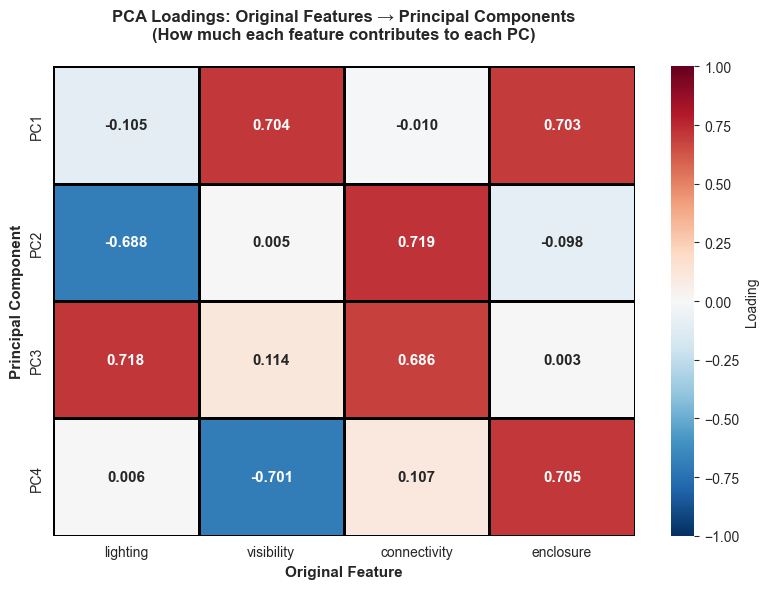

In [13]:
# Visualize loadings as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt='.3f',
            cbar_kws={'label': 'Loading'}, linewidths=1, linecolor='black', 
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
plt.title('PCA Loadings: Original Features → Principal Components\n(How much each feature contributes to each PC)', 
          fontsize=12, fontweight='bold', pad=20)
plt.ylabel('Principal Component', fontsize=11, fontweight='bold')
plt.xlabel('Original Feature', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### PC1 vs PC2 Biplot

**Biplot shows:**
- **Points:** Samples projected onto PC1 & PC2, colored by safety class
- **Arrows:** Original feature vectors showing their contribution to PC1 & PC2

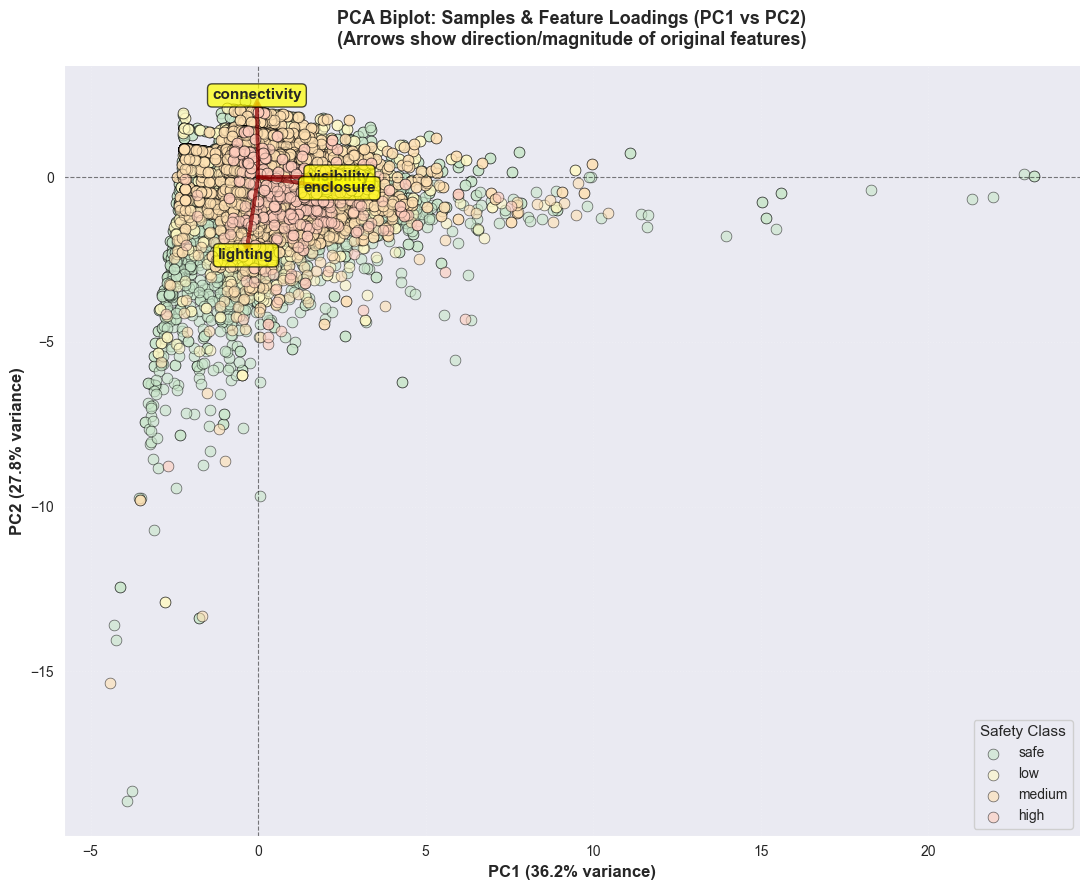

In [14]:
# Prepare biplot data
biplot_df = pd.DataFrame(
    X_pca_full[:, :2],
    columns=['PC1', 'PC2']
)
biplot_df['safety_class'] = y.reset_index(drop=True)

# Create biplot
fig, ax = plt.subplots(figsize=(11, 9))

# Plot samples by class
colors_map = {'safe': '#C8E6C9', 'low': '#FFF9C4', 'medium': '#FFE0B2', 'high': '#FFCCBC'}
for safety_class in ['safe', 'low', 'medium', 'high']:
    mask = biplot_df['safety_class'] == safety_class
    ax.scatter(
        biplot_df.loc[mask, 'PC1'],
        biplot_df.loc[mask, 'PC2'],
        label=safety_class,
        color=colors_map.get(safety_class, 'gray'),
        alpha=0.6,
        s=60,
        edgecolors='black',
        linewidth=0.5
    )

# Plot loading vectors (arrows)
n_features = pca_full.components_.shape[1]
arrow_scale = 3  # Adjust for visibility
loadings_2pc = pca_full.components_[:2, :]

for i, feature in enumerate(FEATURE_COLS):
    ax.arrow(
        0, 0,
        arrow_scale * loadings_2pc[0, i],
        arrow_scale * loadings_2pc[1, i],
        head_width=0.15,
        head_length=0.15,
        fc='red',
        ec='darkred',
        alpha=0.7,
        linewidth=2.5,
        zorder=3
    )
    
    # Label arrows
    ax.text(
        arrow_scale * loadings_2pc[0, i] * 1.15,
        arrow_scale * loadings_2pc[1, i] * 1.15,
        feature,
        fontsize=11,
        fontweight='bold',
        ha='center',
        va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7, edgecolor='black')
    )

# Formatting
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.2, linestyle=':')

ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_title('PCA Biplot: Samples & Feature Loadings (PC1 vs PC2)\n(Arrows show direction/magnitude of original features)', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(title='Safety Class', fontsize=10, title_fontsize=11, loc='best', framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Feature Interaction Analysis

**Pairplot:** Visualize relationships between features, colored by safety class.

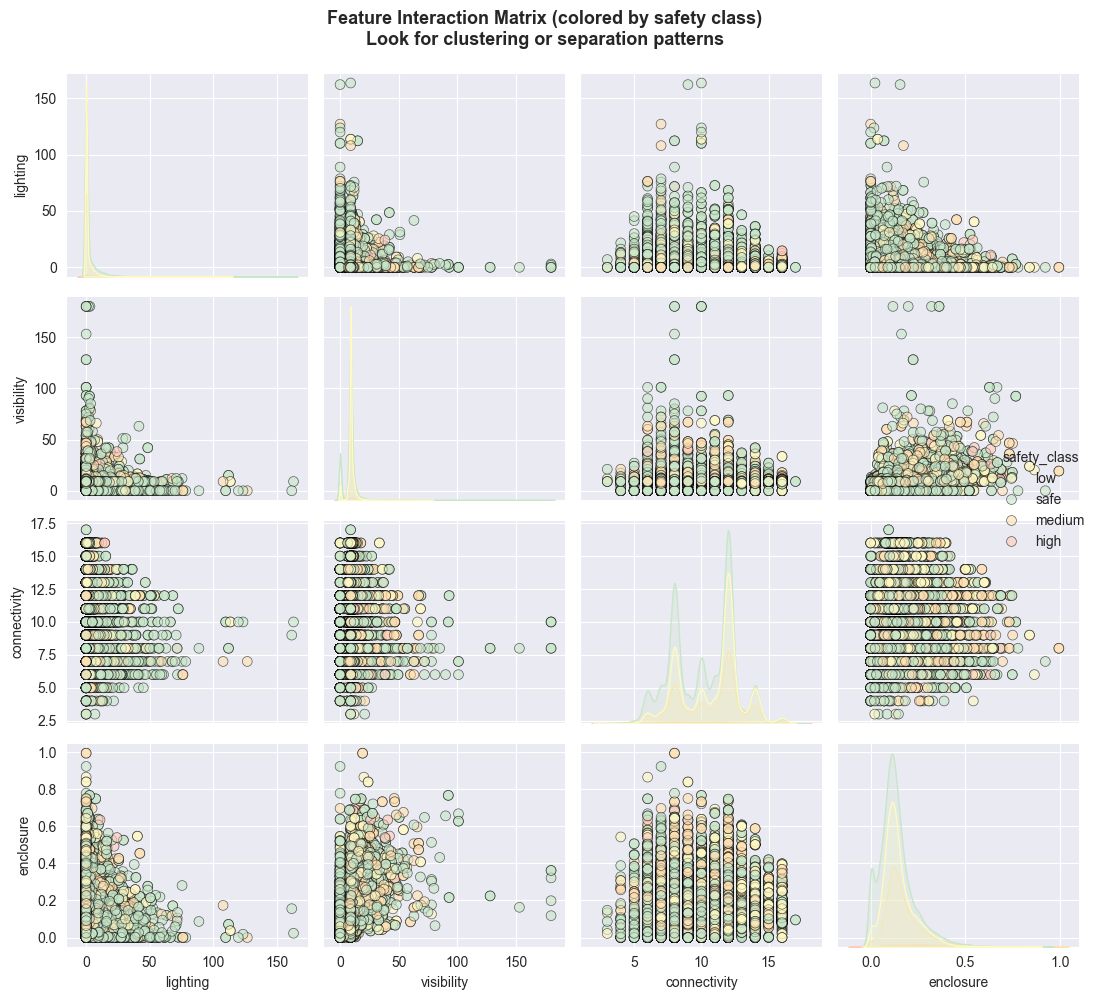

In [15]:
# Create pairplot
pairplot_df = X[FEATURE_COLS].copy().reset_index(drop=True)
pairplot_df['safety_class'] = y.reset_index(drop=True)

# No remapping needed; labels should already be in new 4-class format from 02_ML notebook

pairplot = sns.pairplot(
    pairplot_df,
    hue='safety_class',
    palette={'safe': '#C8E6C9', 'low': '#FFF9C4', 'medium': '#FFE0B2', 'high': '#FFCCBC'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'k', 'linewidth': 0.5},
    height=2.5
)

pairplot.fig.suptitle('Feature Interaction Matrix (colored by safety class)\nLook for clustering or separation patterns', 
                       fontsize=13, fontweight='bold', y=0.995)
pairplot.fig.tight_layout()
plt.show()

## Step 4: Dimensionality Reduction Decision

### Decision Table

In [16]:
print('='*70)
print('DIMENSIONALITY REDUCTION DECISION MATRIX')
print('='*70)

n_pc_90 = np.argmax(cumsum_explained >= 0.90) + 1
n_pc_95 = np.argmax(cumsum_explained >= 0.95) + 1

print(f'\nCriteria:')
print(f'  ✓ Components for 90% variance: {n_pc_90}')
print(f'  ✓ Components for 95% variance: {n_pc_95}')
print(f'  ✓ Original feature count: {len(FEATURE_COLS)}')

# Check correlation
max_corr = 0
for i in range(len(corr_pairs_sorted)):
    _, _, corr_val = corr_pairs_sorted[i]
    if abs(corr_val) > max_corr:
        max_corr = abs(corr_val)

print(f'  ✓ Max absolute correlation: {max_corr:.3f}')
print(f'  ✓ Max VIF: {vif_data["VIF"].max():.2f}')

print('\n' + '='*70)
print('RECOMMENDATION')
print('='*70)

if n_pc_90 <= 2:
    rec = 'STRONG: Apply PCA with 2 components'
    reason = f'Only 2 PCs explain 90% variance. Dimensionality reduction is highly beneficial.'
elif n_pc_90 == len(FEATURE_COLS) - 1:
    rec = 'WEAK: Apply PCA with caution'
    reason = f'Need {n_pc_90} PCs for 90%, only 1 less than original. Marginal benefit.'
elif n_pc_90 >= len(FEATURE_COLS):
    rec = 'NOT RECOMMENDED: Keep original features'
    reason = 'Need all original features; PCA offers no benefit.'
else:
    rec = f'MODERATE: Apply PCA with {n_pc_90} components'
    reason = f'Need {n_pc_90} PCs for 90% variance. Some redundancy detected.'

if max_corr > 0.8:
    rec_alt = f'ALTERNATIVE: Drop one highly-correlated feature ({max_corr:.3f})'
    print(f'{rec}')
    print(f'  Reason: {reason}')
    print(f'\n{rec_alt}')
    print(f'  Reason: Two features are highly correlated. Simpler than PCA, more interpretable.')
else:
    print(f'{rec}')
    print(f'  Reason: {reason}')

print()

DIMENSIONALITY REDUCTION DECISION MATRIX

Criteria:
  ✓ Components for 90% variance: 4
  ✓ Components for 95% variance: 4
  ✓ Original feature count: 4
  ✓ Max absolute correlation: 0.443
  ✓ Max VIF: 1.25

RECOMMENDATION
NOT RECOMMENDED: Keep original features
  Reason: Need all original features; PCA offers no benefit.



## Step 5: Model Comparison

### Compare Performance: Original Features vs. PCA-Reduced

**Key question:** Does PCA maintain (or improve) model performance?

In [17]:
# Debug: Check shapes before train_test_split
print('DEBUG: Checking data shapes before train_test_split')
print(f'X shape: {X.shape}')
print(f'X[FEATURE_COLS] shape: {X[FEATURE_COLS].shape}')
print(f'y shape: {y.shape}')
print(f'y type: {type(y)}')
print(f'X.index length: {len(X.index)}')
print(f'y.index length: {len(y.index)}')
print(f'\nFirst few values of y:')
print(y.head())


DEBUG: Checking data shapes before train_test_split
X shape: (35980, 4)
X[FEATURE_COLS] shape: (35980, 4)
y shape: (35980,)
y type: <class 'pandas.Series'>
X.index length: 35980
y.index length: 35980

First few values of y:
0     low
1     low
2    safe
3    safe
4    safe
Name: safety_class, dtype: str


In [18]:
# ====================================================================================
# PROPER TRAIN/TEST SPLIT WITH STRATIFICATION
# ====================================================================================
# CRITICAL: Fit scaler & PCA on training data ONLY, then transform test data

# Step 1: Split data (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X[FEATURE_COLS],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Data split:')
print(f'  Training set: {len(X_train)} samples')
print(f'  Test set: {len(X_test)} samples')
print(f'\nTraining class distribution:')
print(y_train.value_counts())
print(f'\nTest class distribution:')
print(y_test.value_counts())

Data split:
  Training set: 28784 samples
  Test set: 7196 samples

Training class distribution:
safety_class
safe      13877
low        9070
medium     5521
high        316
Name: count, dtype: int64

Test class distribution:
safety_class
safe      3469
low       2268
medium    1380
high        79
Name: count, dtype: int64


In [19]:
# ====================================================================================
# MODEL 1: ORIGINAL 4 FEATURES (SCALED)
# ====================================================================================

# Scale training data
scaler_m1 = StandardScaler()
X_train_scaled = scaler_m1.fit_transform(X_train)
X_test_scaled = scaler_m1.transform(X_test)  # IMPORTANT: Use training scaler

# Train models
print('Training models on ORIGINAL 4 FEATURES (scaled)...')
lr_orig = LogisticRegression(random_state=42, max_iter=1000)
rf_orig = RandomForestClassifier(n_estimators=5, random_state=42, n_jobs=-1)

lr_orig.fit(X_train_scaled, y_train)
rf_orig.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_orig_lr = lr_orig.predict(X_train_scaled)
y_test_pred_orig_lr = lr_orig.predict(X_test_scaled)

y_train_pred_orig_rf = rf_orig.predict(X_train_scaled)
y_test_pred_orig_rf = rf_orig.predict(X_test_scaled)

# Metrics
acc_train_orig_lr = accuracy_score(y_train, y_train_pred_orig_lr)
acc_test_orig_lr = accuracy_score(y_test, y_test_pred_orig_lr)

acc_train_orig_rf = accuracy_score(y_train, y_train_pred_orig_rf)
acc_test_orig_rf = accuracy_score(y_test, y_test_pred_orig_rf)

print(f'  Logistic Regression: Train acc = {acc_train_orig_lr:.3f}, Test acc = {acc_test_orig_lr:.3f}')
print(f'  Random Forest:       Train acc = {acc_train_orig_rf:.3f}, Test acc = {acc_test_orig_rf:.3f}')
print('✓ Models trained on original features')

Training models on ORIGINAL 4 FEATURES (scaled)...
  Logistic Regression: Train acc = 0.479, Test acc = 0.477
  Random Forest:       Train acc = 0.962, Test acc = 0.752
✓ Models trained on original features


In [20]:
# ====================================================================================
# MODEL 2: PCA-REDUCED FEATURES (2 COMPONENTS)
# ====================================================================================
# Choose n_components based on the variance analysis above
# Start with 2; if results are poor, try 3.

n_components_pca = 2  # ← ADJUST based on your variance analysis

print(f'\nTraining models on PCA-REDUCED features ({n_components_pca} components)...')

# Scale training data (same scaler as Model 1)
# Fit PCA on training data only
pca_model = PCA(n_components=n_components_pca)
X_train_pca = pca_model.fit_transform(X_train_scaled)  # Fit on training data
X_test_pca = pca_model.transform(X_test_scaled)  # Transform test data (don't fit)

# Train models
lr_pca = LogisticRegression(random_state=42, max_iter=1000)
rf_pca = RandomForestClassifier(n_estimators=5, random_state=42, n_jobs=-1)

lr_pca.fit(X_train_pca, y_train)
rf_pca.fit(X_train_pca, y_train)

# Predictions
y_train_pred_pca_lr = lr_pca.predict(X_train_pca)
y_test_pred_pca_lr = lr_pca.predict(X_test_pca)

y_train_pred_pca_rf = rf_pca.predict(X_train_pca)
y_test_pred_pca_rf = rf_pca.predict(X_test_pca)

# Metrics
acc_train_pca_lr = accuracy_score(y_train, y_train_pred_pca_lr)
acc_test_pca_lr = accuracy_score(y_test, y_test_pred_pca_lr)

acc_train_pca_rf = accuracy_score(y_train, y_train_pred_pca_rf)
acc_test_pca_rf = accuracy_score(y_test, y_test_pred_pca_rf)

print(f'  Logistic Regression: Train acc = {acc_train_pca_lr:.3f}, Test acc = {acc_test_pca_lr:.3f}')
print(f'  Random Forest:       Train acc = {acc_train_pca_rf:.3f}, Test acc = {acc_test_pca_rf:.3f}')
print(f'✓ Models trained on PCA-reduced features ({n_components_pca} PCs)')


Training models on PCA-REDUCED features (2 components)...
  Logistic Regression: Train acc = 0.479, Test acc = 0.477
  Random Forest:       Train acc = 0.961, Test acc = 0.754
✓ Models trained on PCA-reduced features (2 PCs)


In [21]:
# ====================================================================================
# SIDE-BY-SIDE COMPARISON
# ====================================================================================

comparison_results = pd.DataFrame({
    'Model': [
        f'Logistic (Original, 4 features)',
        f'Logistic (PCA-{n_components_pca})',
        f'Random Forest (Original, 4 features)',
        f'Random Forest (PCA-{n_components_pca})'
    ],
    'Train Acc': [
        acc_train_orig_lr,
        acc_train_pca_lr,
        acc_train_orig_rf,
        acc_train_pca_rf
    ],
    'Test Acc': [
        acc_test_orig_lr,
        acc_test_pca_lr,
        acc_test_orig_rf,
        acc_test_pca_rf
    ],
    'Overfit Gap': [
        acc_train_orig_lr - acc_test_orig_lr,
        acc_train_pca_lr - acc_test_pca_lr,
        acc_train_orig_rf - acc_test_orig_rf,
        acc_train_pca_rf - acc_test_pca_rf
    ]
})

print('\n' + '='*90)
print('MODEL PERFORMANCE COMPARISON: Original Features vs. PCA-Reduced')
print('='*90)
print(comparison_results.to_string(index=False))

print('\n' + '='*90)
print('INTERPRETATION')
print('='*90)

lr_orig_test = acc_test_orig_lr
lr_pca_test = acc_test_pca_lr
lr_diff = lr_pca_test - lr_orig_test

rf_orig_test = acc_test_orig_rf
rf_pca_test = acc_test_pca_rf
rf_diff = rf_pca_test - rf_orig_test

print(f'\nLogistic Regression:')
print(f'  Original: {lr_orig_test:.3f}  |  PCA: {lr_pca_test:.3f}  |  Difference: {lr_diff:+.3f}')
if abs(lr_diff) < 0.02:
    print(f'  → Performance is SIMILAR. PCA is viable (fewer features, simpler model).')
elif lr_diff > 0:
    print(f'  → Performance IMPROVED with PCA! (noise reduction)')
else:
    print(f'  → Performance DEGRADED with PCA. Keep original features.')

print(f'\nRandom Forest:')
print(f'  Original: {rf_orig_test:.3f}  |  PCA: {rf_pca_test:.3f}  |  Difference: {rf_diff:+.3f}')
if abs(rf_diff) < 0.02:
    print(f'  → Performance is SIMILAR. PCA is viable (fewer features, simpler model).')
elif rf_diff > 0:
    print(f'  → Performance IMPROVED with PCA! (noise reduction)')
else:
    print(f'  → Performance DEGRADED with PCA. Keep original features.')

# Overfitting check
print(f'\nOverfitting Analysis (Train - Test gap):')
gap_orig_lr = acc_train_orig_lr - acc_test_orig_lr
gap_pca_lr = acc_train_pca_lr - acc_test_pca_lr
print(f'  LR Original: {gap_orig_lr:.3f}  |  LR PCA: {gap_pca_lr:.3f}')
if gap_pca_lr < gap_orig_lr:
    print(f'    → PCA REDUCED overfitting (smaller gap)')
else:
    print(f'    → PCA INCREASED or MAINTAINED overfitting')

gap_orig_rf = acc_train_orig_rf - acc_test_orig_rf
gap_pca_rf = acc_train_pca_rf - acc_test_pca_rf
print(f'  RF Original: {gap_orig_rf:.3f}  |  RF PCA: {gap_pca_rf:.3f}')
if gap_pca_rf < gap_orig_rf:
    print(f'    → PCA REDUCED overfitting (smaller gap)')
else:
    print(f'    → PCA INCREASED or MAINTAINED overfitting')


MODEL PERFORMANCE COMPARISON: Original Features vs. PCA-Reduced
                               Model  Train Acc  Test Acc  Overfit Gap
     Logistic (Original, 4 features)     0.4789    0.4768       0.0021
                    Logistic (PCA-2)     0.4786    0.4769       0.0017
Random Forest (Original, 4 features)     0.9620    0.7522       0.2097
               Random Forest (PCA-2)     0.9612    0.7544       0.2067

INTERPRETATION

Logistic Regression:
  Original: 0.477  |  PCA: 0.477  |  Difference: +0.000
  → Performance is SIMILAR. PCA is viable (fewer features, simpler model).

Random Forest:
  Original: 0.752  |  PCA: 0.754  |  Difference: +0.002
  → Performance is SIMILAR. PCA is viable (fewer features, simpler model).

Overfitting Analysis (Train - Test gap):
  LR Original: 0.002  |  LR PCA: 0.002
    → PCA REDUCED overfitting (smaller gap)
  RF Original: 0.210  |  RF PCA: 0.207
    → PCA REDUCED overfitting (smaller gap)


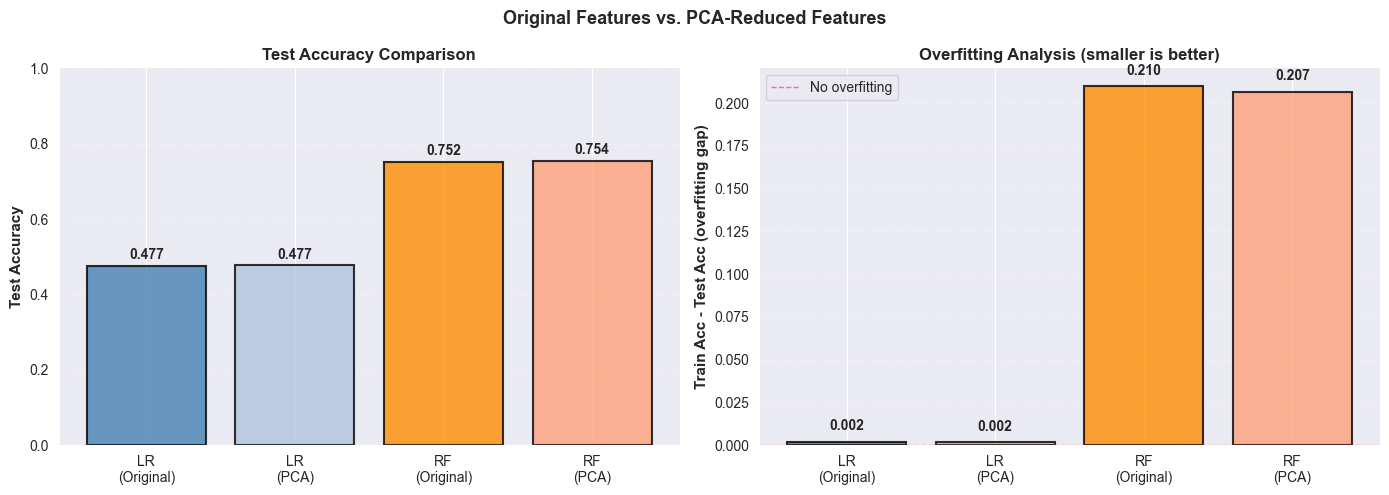

In [22]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test accuracy comparison
ax1 = axes[0]
models = ['LR\n(Original)', 'LR\n(PCA)', 'RF\n(Original)', 'RF\n(PCA)']
test_accs = [acc_test_orig_lr, acc_test_pca_lr, acc_test_orig_rf, acc_test_pca_rf]
colors = ['steelblue', 'lightsteelblue', 'darkorange', 'lightsalmon']

bars = ax1.bar(models, test_accs, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines[['top', 'right']].set_visible(False)

# Add value labels
for bar, acc in zip(bars, test_accs):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Overfitting gap comparison
ax2 = axes[1]
overfit_gaps = [
    acc_train_orig_lr - acc_test_orig_lr,
    acc_train_pca_lr - acc_test_pca_lr,
    acc_train_orig_rf - acc_test_orig_rf,
    acc_train_pca_rf - acc_test_pca_rf
]

bars2 = ax2.bar(models, overfit_gaps, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Train Acc - Test Acc (overfitting gap)', fontsize=11, fontweight='bold')
ax2.set_title('Overfitting Analysis (smaller is better)', fontsize=12, fontweight='bold')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='No overfitting')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=10)

# Add value labels
for bar, gap in zip(bars2, overfit_gaps):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{gap:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Original Features vs. PCA-Reduced Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Confusion Matrices: Detailed Error Analysis

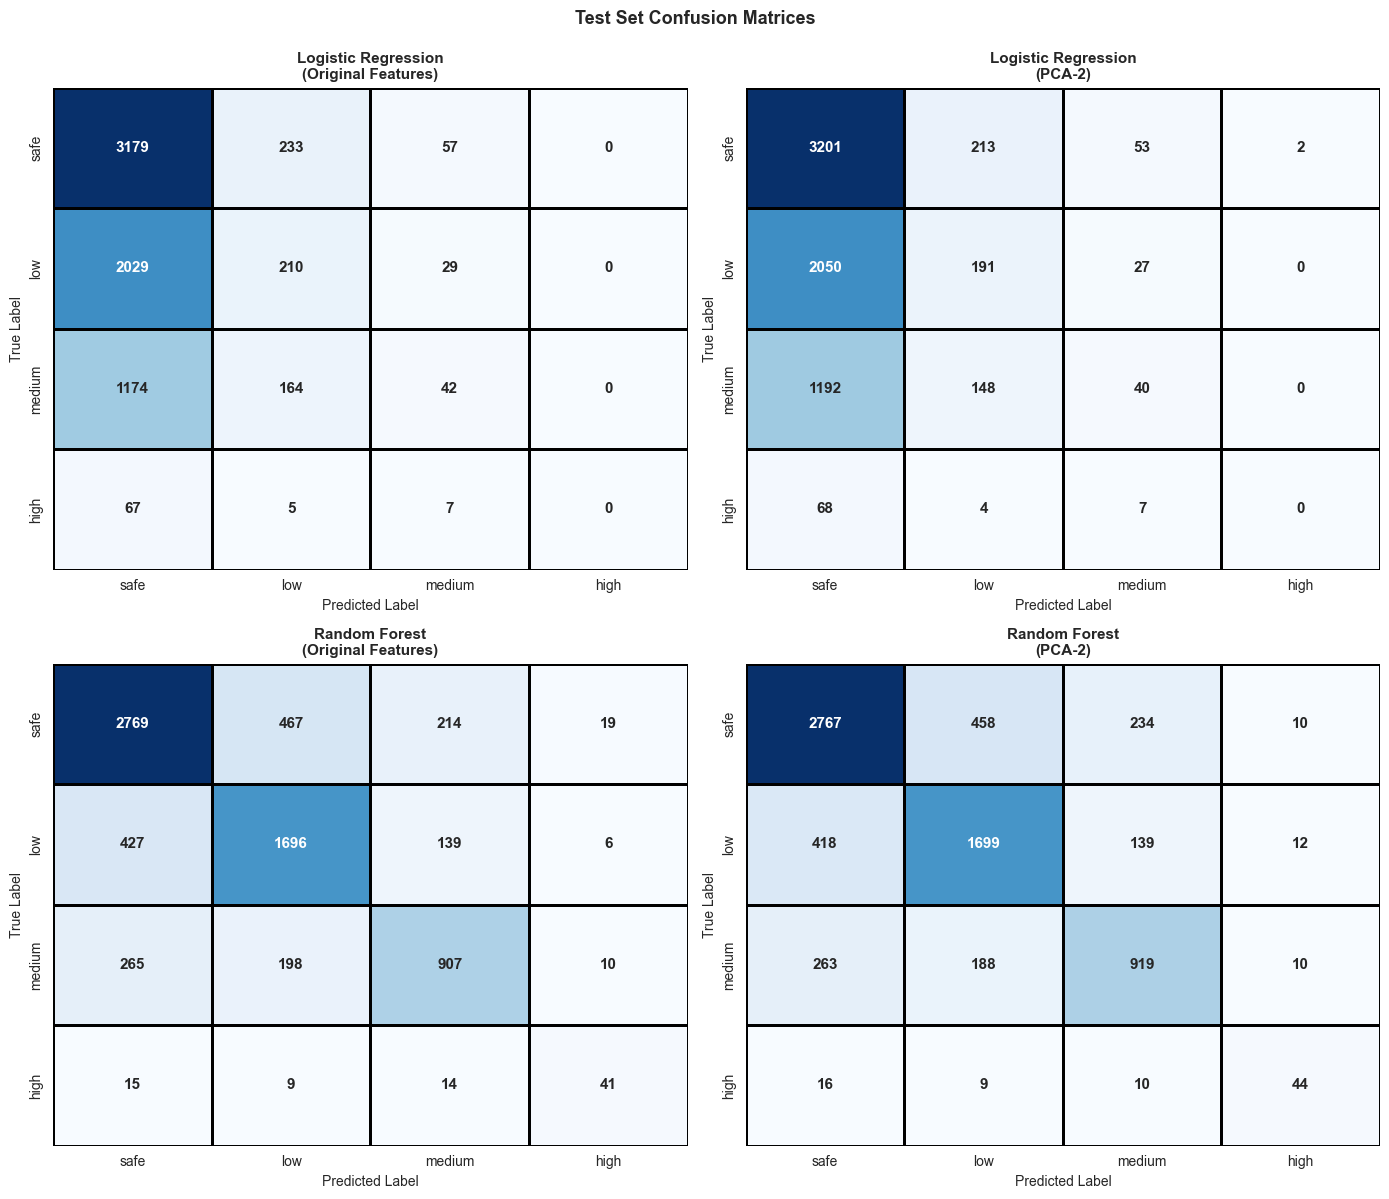

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Use 4-class system labels (same order as in 02_ML notebook)
# No remapping needed if data came from updated 02_ML notebook
y_test_remapped = y_test
y_test_pred_orig_lr_remapped = y_test_pred_orig_lr
y_test_pred_pca_lr_remapped = y_test_pred_pca_lr
y_test_pred_orig_rf_remapped = y_test_pred_orig_rf
y_test_pred_pca_rf_remapped = y_test_pred_pca_rf

# ALWAYS use all four classes in correct order to ensure consistency in matrix display
classes = ['safe', 'low', 'medium', 'high']

cm_orig_lr = confusion_matrix(y_test_remapped, y_test_pred_orig_lr_remapped, labels=classes)
cm_pca_lr = confusion_matrix(y_test_remapped, y_test_pred_pca_lr_remapped, labels=classes)
cm_orig_rf = confusion_matrix(y_test_remapped, y_test_pred_orig_rf_remapped, labels=classes)
cm_pca_rf = confusion_matrix(y_test_remapped, y_test_pred_pca_rf_remapped, labels=classes)

matrices = [
    (cm_orig_lr, 'Logistic Regression\n(Original Features)', axes[0, 0]),
    (cm_pca_lr, f'Logistic Regression\n(PCA-{n_components_pca})', axes[0, 1]),
    (cm_orig_rf, 'Random Forest\n(Original Features)', axes[1, 0]),
    (cm_pca_rf, f'Random Forest\n(PCA-{n_components_pca})', axes[1, 1])
]

for cm, title, ax in matrices:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes,
                ax=ax, cbar=False, linewidths=1, linecolor='black',
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.suptitle('Test Set Confusion Matrices', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Final Summary & Recommendations

In [21]:
print('\n' + '='*90)
print('FINAL DIMENSIONALITY REDUCTION SUMMARY')
print('='*90)

print('\n1. FEATURE CORRELATION ANALYSIS')
print('-' * 90)
if max_corr > 0.8:
    print(f'   ⚠ HIGH CORRELATION DETECTED: {max_corr:.3f}')
    print(f'   → Consider dropping one feature instead of PCA (more interpretable)')
else:
    print(f'   ✓ No high correlations (max = {max_corr:.3f})')
    print(f'   → Features are relatively independent')

print('\n2. PCA VARIANCE ANALYSIS')
print('-' * 90)
print(f'   • 90% variance explained by: {n_pc_90} components (out of {len(FEATURE_COLS)})')
print(f'   • 95% variance explained by: {n_pc_95} components (out of {len(FEATURE_COLS)})')
if n_pc_90 <= 2:
    print(f'   → STRONG reduction potential (≥ 2 fewer components)')
elif n_pc_90 == len(FEATURE_COLS):
    print(f'   → NO reduction potential (need all {len(FEATURE_COLS)} components)')
else:
    print(f'   → MODERATE reduction potential ({len(FEATURE_COLS) - n_pc_90} fewer components)')

print('\n3. MODEL PERFORMANCE')
print('-' * 90)
lr_diff_pct = abs(lr_diff) * 100
rf_diff_pct = abs(rf_diff) * 100
print(f'   Logistic Regression: Test acc change = {lr_diff:+.1%} ({"✓ acceptable" if abs(lr_diff) < 0.05 else "✗ significant loss"})')
print(f'   Random Forest: Test acc change = {rf_diff:+.1%} ({"✓ acceptable" if abs(rf_diff) < 0.05 else "✗ significant loss"})')

print('\n4. MULTICOLLINEARITY CHECK (VIF)')
print('-' * 90)
max_vif = vif_data['VIF'].max()
if max_vif > 10:
    print(f'   ⚠ HIGH MULTICOLLINEARITY: max VIF = {max_vif:.2f}')
    print(f'   → PCA is recommended to handle collinearity')
elif max_vif > 5:
    print(f'   ⚠ MODERATE MULTICOLLINEARITY: max VIF = {max_vif:.2f}')
    print(f'   → PCA may help, but optional')
else:
    print(f'   ✓ LOW MULTICOLLINEARITY: max VIF = {max_vif:.2f}')
    print(f'   → No collinearity issues; PCA not necessary on this basis')

print('\n' + '='*90)
print('FINAL RECOMMENDATION')
print('='*90)

if n_pc_90 <= 2 and abs(lr_diff) < 0.05 and abs(rf_diff) < 0.05:
    print(f'\n✓✓✓ APPLY PCA with {n_components_pca} components')
    print('    Reason: Significant dimensionality reduction, no performance loss')
    print('    Benefit: Simpler models, reduced overfitting, better visualization')
elif abs(lr_diff) < 0.02 and abs(rf_diff) < 0.02:
    print(f'\n✓ OPTIONAL: Apply PCA with {n_components_pca} components')
    print('    Reason: Performance maintained, some redundancy detected')
    print('    Benefit: Modest improvement in model simplicity')
else:
    print(f'\n✗ NOT RECOMMENDED: Keep original {len(FEATURE_COLS)} features')
    print('    Reason: Limited redundancy or performance degradation with PCA')
    print('    Alternative: Drop the lighting feature (known data quality issue)')

print('\n' + '='*90)
print('NEXT STEPS')
print('='*90)
print('\n1. Merge this notebook with your ML notebook for end-to-end pipeline')
print('2. If applying PCA: Replace X with X_pca in your classification model')
print('3. If not applying PCA: Consider removing the lighting feature (low signal)')
print('4. Document your decision and reasoning for reproducibility')
print('\n' + '='*90)


FINAL DIMENSIONALITY REDUCTION SUMMARY

1. FEATURE CORRELATION ANALYSIS
------------------------------------------------------------------------------------------
   ✓ No high correlations (max = 0.443)
   → Features are relatively independent

2. PCA VARIANCE ANALYSIS
------------------------------------------------------------------------------------------
   • 90% variance explained by: 4 components (out of 4)
   • 95% variance explained by: 4 components (out of 4)
   → NO reduction potential (need all 4 components)

3. MODEL PERFORMANCE
------------------------------------------------------------------------------------------
   Logistic Regression: Test acc change = -0.2% (✓ acceptable)
   Random Forest: Test acc change = -0.2% (✓ acceptable)

4. MULTICOLLINEARITY CHECK (VIF)
------------------------------------------------------------------------------------------
   ✓ LOW MULTICOLLINEARITY: max VIF = 1.25
   → No collinearity issues; PCA not necessary on this basis

FINAL RECOM